In [1]:
import bw2data, bw2io, bw2calc
import numpy as np
import os
import re
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append('../../utils/') 
from post_anal_plot import * 

### static LCI +  three GWP
- GWP100
- pGWP-fixed vs. dp-CO2 

In [3]:
wind  = pd.read_excel("../dp-LCI_output/staticLCI_(p)GWP100/wind_CN_US_staticLCI_threeGWP100.xlsx")
hydro = pd.read_excel("../dp-LCI_output/staticLCI_(p)GWP100/hydro_run-of-river_CN_US_staticLCI_threeGWP100.xlsx")
pv    = pd.read_excel("../dp-LCI_output/staticLCI_(p)GWP100/PV_CN_US_staticLCI_threeGWP100.xlsx")

In [3]:

def tidy(df, tech_label):
    parts = df["Activity"].str.split(", ", expand=True)
    out = df.copy()
    out["Technology"] = tech_label
    out["Country"]    = parts[3].str[:2]
    out["SSP"]        = parts[4]
    out["Year"]       = parts[5].astype(int)
    return out[["Technology", "Country", "SSP", "Year",
                "gwp100", "pGWP100_fixedCO2", "pGWP100_dpCO2"]]

all_df = pd.concat(
    [tidy(wind,  "Wind"),
     tidy(hydro, "Hydro"),
     tidy(pv,    "PV")],
    ignore_index=True,
)

# Keep only 2030 & 2050
df = all_df[all_df["Year"].isin([2030, 2050])].copy()

# long format over metrics
metric_cols = ["gwp100", "pGWP100_fixedCO2", "pGWP100_dpCO2"]
df_long = df.melt(
    id_vars=["Technology", "Country", "SSP", "Year"],
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Score",
)

df_long


,Technology,Country,SSP,Year,Metric,Score
0,Wind,CN,SSP1-VLLO,2030,gwp100,0.036905
1,Wind,CN,SSP1-VLLO,2050,gwp100,0.017832
2,Wind,CN,SSP2-M,2030,gwp100,0.037723
3,Wind,CN,SSP2-M,2050,gwp100,0.031185
4,Wind,CN,SSP5-H,2030,gwp100,0.038734
...,...,...,...,...,...,...
103,PV,US,SSP1-VLLO,2050,pGWP100_dpCO2,0.006184
104,PV,US,SSP2-M,2030,pGWP100_dpCO2,0.020048
105,PV,US,SSP2-M,2050,pGWP100_dpCO2,0.012654
106,PV,US,SSP5-H,2030,pGWP100_dpCO2,0.020952


#### adding:  dpLCI + pGWP-fixedCO2

In [4]:

with open("../dp-LCI_output/dpLCI_pGWP-fixed_pickle/hydro_dp_results_MY2030_2050.pkl","rb") as f:
    hydro_dp = pickle.load(f)

with open("../dp-LCI_output/dpLCI_pGWP-fixed_pickle/PV_dp_results_MY2030_2050.pkl","rb") as f:
    pv_dp = pickle.load(f)

with open("../dp-LCI_output/dpLCI_pGWP-fixed_pickle/wind_dp_results_allMY.pkl","rb") as f:
    wind_dp = pickle.load(f)


# extract the new dp metrics and produce a DataFrame with exact columns:
# Activity, Technology, Country, SSP, Year, Metric, Score
# ONLY WANNA 2030 & 2050 as two MY:: 

def extract_from_dp_dict(dp_dict):
    rows = []

    # map activity string tech → tidy Technology label
    tech_map = {
        "wind": "Wind",
        "PV": "PV",
        "hydro": "Hydro",
    }

    #####   we need to convert all US-xx / CN-xx country code to just US/CN 
    def collapse_country(region):
        """Collapse ecoinvent/IAM region to CN or US."""
        if region.startswith("US"):
            return "US"
        if region.startswith("CN"):
            return "CN"
        # if you ever have other regions, either return as-is or map them too
        return region

    for act, metrics in dp_dict.items():
        parts = act.split(", ")

        raw_tech = parts[1]              # 'wind' / 'photovoltaic' / 'hydro'
        if raw_tech not in tech_map:
            print(row_tech)
            continue                     # skip unexpected techs

        tech        = tech_map[raw_tech]
        region      = parts[3]           # e.g. 'US-TRE', 'CN-NM'
        country     = collapse_country(region)
        ssp         = parts[4]
        year        = int(parts[5])

        # keep only 2030 & 2050
        if year not in (2030, 2050):
            continue

        for metric_name, value in metrics.items():
            rows.append(
                {
                    "Technology": tech,
                    "Country": country,   # NOW only 'US' or 'CN'
                    "SSP": ssp,
                    "Year": year,
                    "Metric": metric_name,
                    "Score": float(value),
                }
            )

    return pd.DataFrame(rows)



df_hydro_dp = extract_from_dp_dict(hydro_dp)
df_pv_dp    = extract_from_dp_dict(pv_dp)
df_wind_dp  = extract_from_dp_dict(wind_dp)

df_dp = pd.concat([df_hydro_dp, df_pv_dp, df_wind_dp], ignore_index=True)
print(len(df_dp)) # should be 72, so that 72/2(new metric) == 36
df_dp


72


,Technology,Country,SSP,Year,Metric,Score
0,Hydro,US,SSP5-H,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.004793
1,Hydro,US,SSP5-H,2030,"full dp-LCI, pGWP100-fixedCO2",0.004745
2,Hydro,US,SSP1-VLLO,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.004835
3,Hydro,US,SSP1-VLLO,2030,"full dp-LCI, pGWP100-fixedCO2",0.004956
4,Hydro,CN,SSP2-M,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.003733
...,...,...,...,...,...,...
67,Wind,US,SSP1-VLLO,2030,"full dp-LCI, pGWP100-fixedCO2",0.024138
68,Wind,US,SSP2-M,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.017229
69,Wind,US,SSP2-M,2050,"full dp-LCI, pGWP100-fixedCO2",0.021193
70,Wind,CN,SSP1-VLLO,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.041520


In [5]:
#df_dp 
df_full = pd.concat([df_long, df_dp], ignore_index=True)
#df_full

#### now ranking 

In [6]:
# NOW recompute Rank with the two new metrics included
df_full["Rank"] = df_full.groupby(
    ["Country","SSP","Year","Metric"]
)["Score"].rank(method="dense", ascending=True)

df_full

,Technology,Country,SSP,Year,Metric,Score,Rank
0,Wind,CN,SSP1-VLLO,2030,gwp100,0.036905,3.0
1,Wind,CN,SSP1-VLLO,2050,gwp100,0.017832,3.0
2,Wind,CN,SSP2-M,2030,gwp100,0.037723,3.0
3,Wind,CN,SSP2-M,2050,gwp100,0.031185,3.0
4,Wind,CN,SSP5-H,2030,gwp100,0.038734,3.0
...,...,...,...,...,...,...,...
175,Wind,US,SSP1-VLLO,2030,"full dp-LCI, pGWP100-fixedCO2",0.024138,3.0
176,Wind,US,SSP2-M,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.017229,3.0
177,Wind,US,SSP2-M,2050,"full dp-LCI, pGWP100-fixedCO2",0.021193,3.0
178,Wind,CN,SSP1-VLLO,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.041520,3.0


In [7]:
metric_rename = {
    "gwp100": "staticLCI + IPCC-GWP",
    "pGWP100_fixedCO2": "staticLCI + pGWP-fixedCO2",
    "pGWP100_dpCO2": "staticLCI + pGWP-dpCO2",
    "dyn FG LCI static BG p-LCI, pGWP100-fixedCO2": "dyn-FG-LCI + pGWP-fixedCO2",
    "full dp-LCI, pGWP100-fixedCO2": "full dpLCI + pGWP-fixedCO2"
}


In [8]:
df_full["Metric"] = df_full["Metric"].replace(metric_rename)

In [9]:
df_full_sorted = df_full.sort_values([ "SSP","Year", "Country", "Technology"	]) 
df_full_sorted

,Technology,Country,SSP,Year,Metric,Score,Rank
12,Hydro,CN,SSP1-VLLO,2030,staticLCI + IPCC-GWP,0.004278,1.0
48,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-fixedCO2,0.004835,1.0
84,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-dpCO2,0.004232,1.0
126,Hydro,CN,SSP1-VLLO,2030,dyn-FG-LCI + pGWP-fixedCO2,0.004835,1.0
127,Hydro,CN,SSP1-VLLO,2030,full dpLCI + pGWP-fixedCO2,0.004956,1.0
...,...,...,...,...,...,...,...
11,Wind,US,SSP5-H,2050,staticLCI + IPCC-GWP,0.019234,3.0
47,Wind,US,SSP5-H,2050,staticLCI + pGWP-fixedCO2,0.017215,3.0
83,Wind,US,SSP5-H,2050,staticLCI + pGWP-dpCO2,0.019006,3.0
168,Wind,US,SSP5-H,2050,dyn-FG-LCI + pGWP-fixedCO2,0.017215,3.0


In [10]:
df_full_sorted.to_excel("plot_rankshift_five_metrics.xlsx")

## plot 

In [3]:
df_full = pd.read_excel("plot_rankshift_hydro_v2_reservoir.xlsx")
#df_full_sorted.head()

# remove the index column if present
if "Unnamed: 0" in df_full.columns:
    df_full = df_full.drop(columns=["Unnamed: 0"])


In [4]:
metric_order = [
    "staticLCI + IPCC-GWP",
    "staticLCI + pGWP-dpCO2",
    "staticLCI + pGWP-fixedCO2",
    "dyn-FG-LCI + pGWP-fixedCO2",
    "full dpLCI + pGWP-fixedCO2"
]

metric_labels = {m: m for m in metric_order}


### barplot function: to show real magnitude : 

- we put normalized 2050 scores (lower than the 2030) as basebar,
- then put the normalized 2030 scores on top as a stacked bar

### then normalization choice determines whether wind’s 2030 bar disappears (or becomes visually misleading) 
- now we normalize 2030 and 2050 separately, but then wind (2030 vs. 2050 diff) disappears


#### function1

#####  because it's uniform distribution on the FG dyn LCI, 
##### so without full dpLCI (mapping to the right background), it the same score on dyn-FG-LCI vs. static LCI 

In [3]:
df_full.head()

,Technology,Country,SSP,Year,Metric,Score,Rank
0,Hydro,CN,SSP1-VLLO,2030,staticLCI + IPCC-GWP,0.050523,3
1,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-fixedCO2,0.057266,3
2,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-dpCO2,0.050021,3
3,Hydro,CN,SSP1-VLLO,2030,dyn-FG-LCI + pGWP-fixedCO2,0.057266,3
4,Hydro,CN,SSP1-VLLO,2030,full dpLCI + pGWP-fixedCO2,0.057505,3


#### function 2 : just one year 2030 or 2050, not mixing in one plot 

##### function

##### plot

(<Figure size 1400x1000 with 6 Axes>,
 array([[<Axes: title={'center': 'CN, SSP1-19'}, ylabel='Normalized impact (%)'>,
         <Axes: title={'center': 'US, SSP1-19'}>],
        [<Axes: title={'center': 'CN, SSP2-45'}, ylabel='Normalized impact (%)'>,
         <Axes: title={'center': 'US, SSP2-45'}>],
        [<Axes: title={'center': 'CN, SSP5-85'}, ylabel='Normalized impact (%)'>,
         <Axes: title={'center': 'US, SSP5-85'}>]], dtype=object))

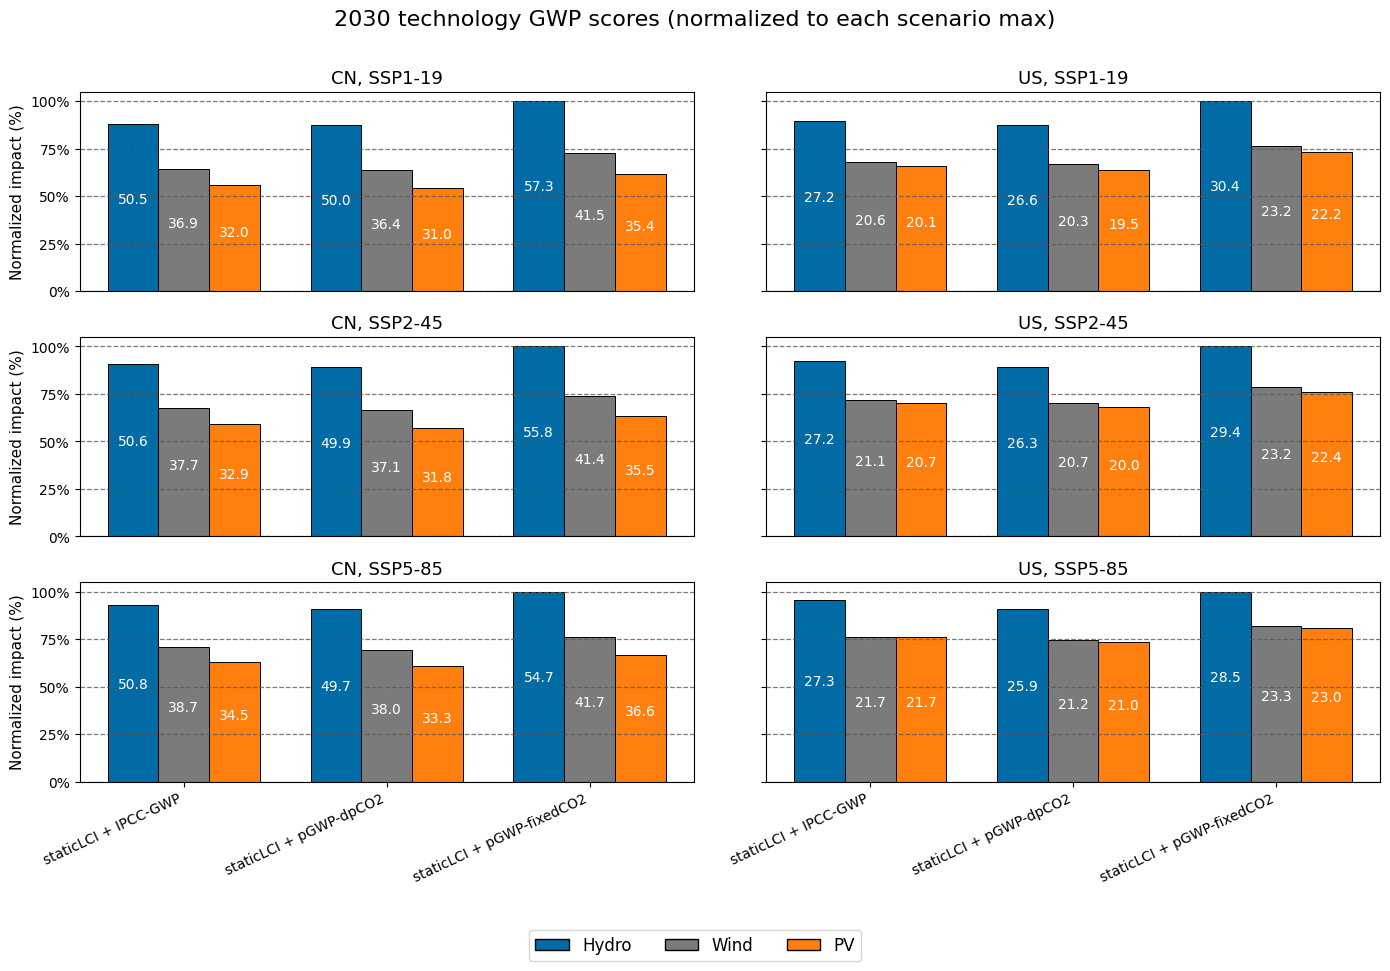

In [5]:
metric_order = [
    "staticLCI + IPCC-GWP",
    "staticLCI + pGWP-dpCO2",
    "staticLCI + pGWP-fixedCO2",
    #"dyn-FG-LCI + pGWP-fixedCO2",
    #"full dpLCI + pGWP-fixedCO2"
]


tech_colors = {
    "Hydro": "#006BA4",
    "Wind":  "#7B7B7B",
    "PV":    "#FF800E"
}

df_full_filt = df_full[df_full["Metric"].isin(metric_order)].copy()

#plot_bar_oneyear_only(df_full, 2050, metric_order, metric_labels, tech_colors)
plot_bar_oneyear_only(df_full_filt, 2030, metric_order, metric_labels, tech_colors)


(<Figure size 1400x1000 with 6 Axes>,
 array([[<Axes: title={'center': 'CN, SSP1-19'}, ylabel='Normalized impact (%)'>,
         <Axes: title={'center': 'US, SSP1-19'}>],
        [<Axes: title={'center': 'CN, SSP2-45'}, ylabel='Normalized impact (%)'>,
         <Axes: title={'center': 'US, SSP2-45'}>],
        [<Axes: title={'center': 'CN, SSP5-85'}, ylabel='Normalized impact (%)'>,
         <Axes: title={'center': 'US, SSP5-85'}>]], dtype=object))

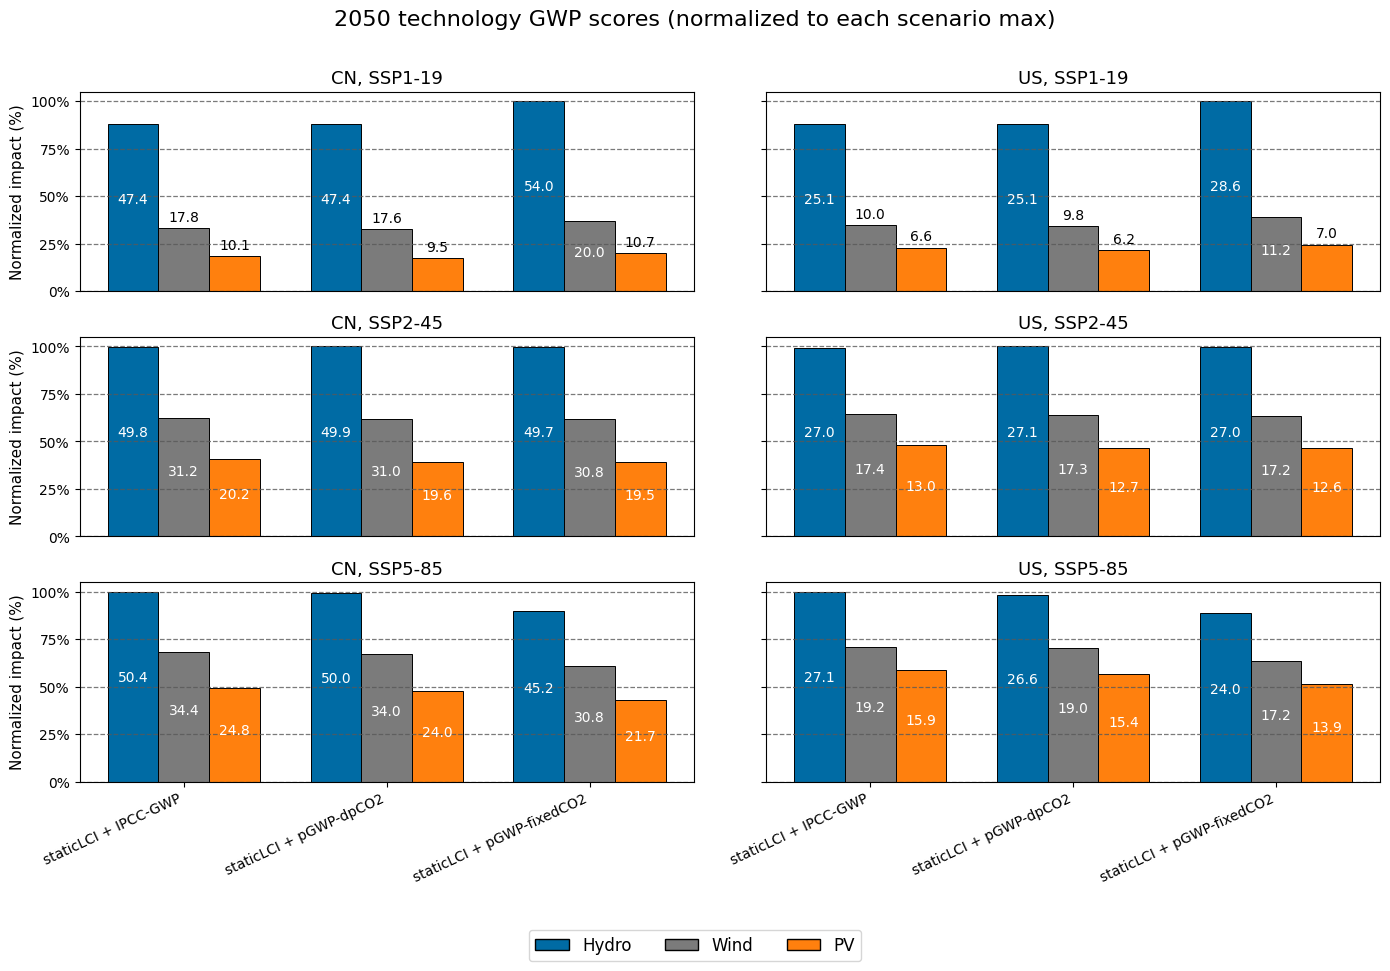

In [6]:
plot_bar_oneyear_only(df_full_filt, 2050, metric_order, metric_labels, tech_colors)

### function3: one region two MY as subplots: 


#### funciton

#### plot one region, two years

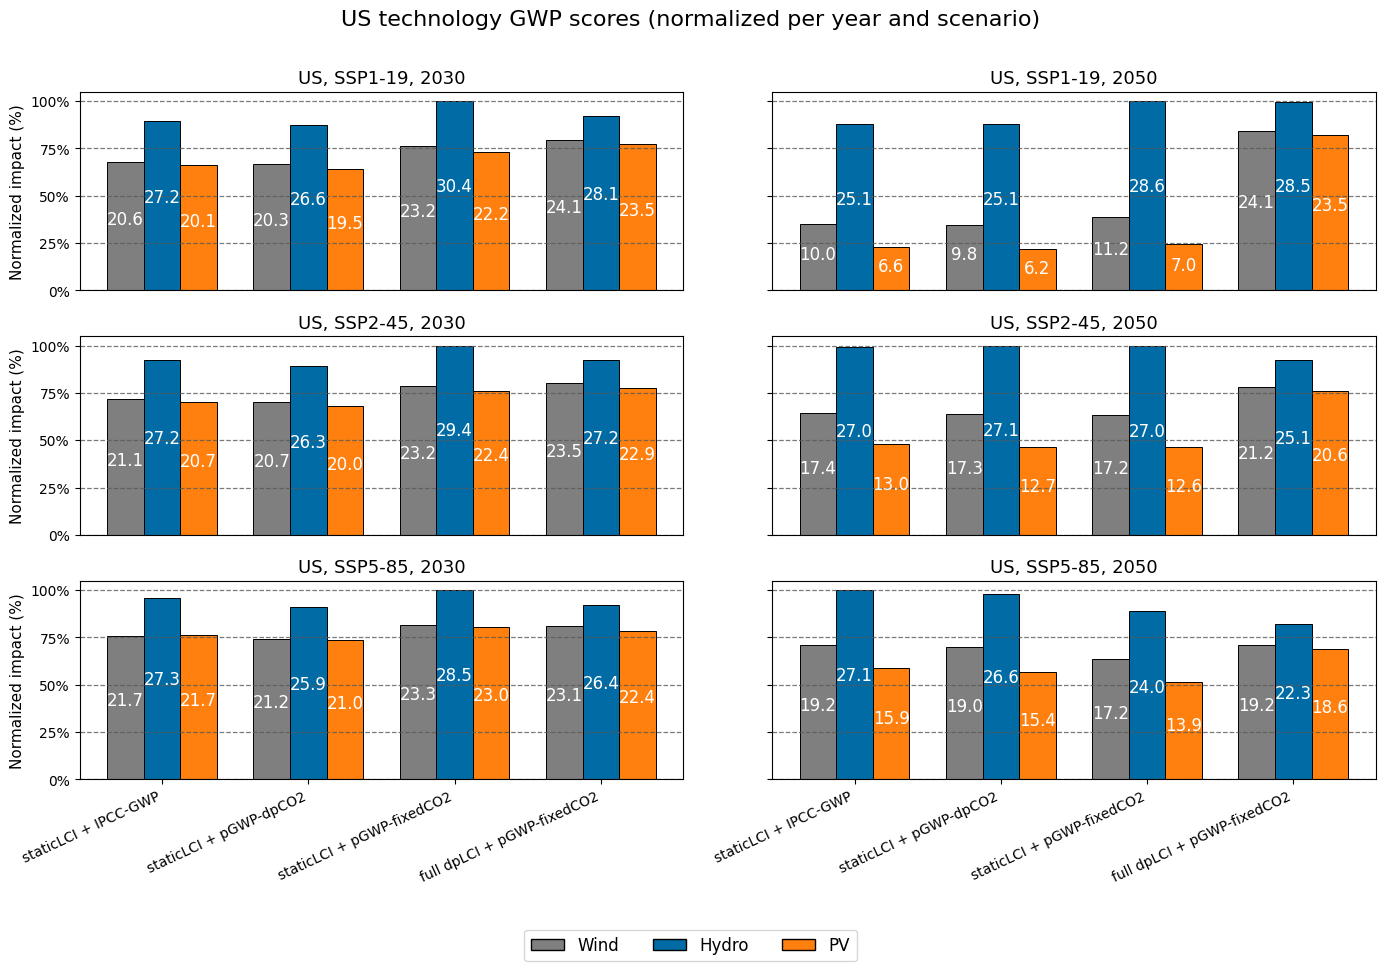

In [5]:
# let's filter out only three metric (caz we not suggest using pGWP100-dpCO2 anyways)
metric_order = [
    "staticLCI + IPCC-GWP",
    "staticLCI + pGWP-dpCO2",
    "staticLCI + pGWP-fixedCO2",
    #"dyn-FG-LCI + pGWP-fixedCO2",
    "full dpLCI + pGWP-fixedCO2"
]

tech_colors = {"PV":"#FF800E","Wind": "#7F7F7F" ,"Hydro": "#006BA4"}


df_full_filt = df_full[df_full["Metric"].isin(metric_order)].copy()


fig, axes = plot_bar_oneregion_twoyears(
    df_full=df_full_filt,
    years=(2030, 2050),
    country="US",
    metric_order=metric_order,
    metric_labels=metric_labels,
    tech_colors=tech_colors,
)


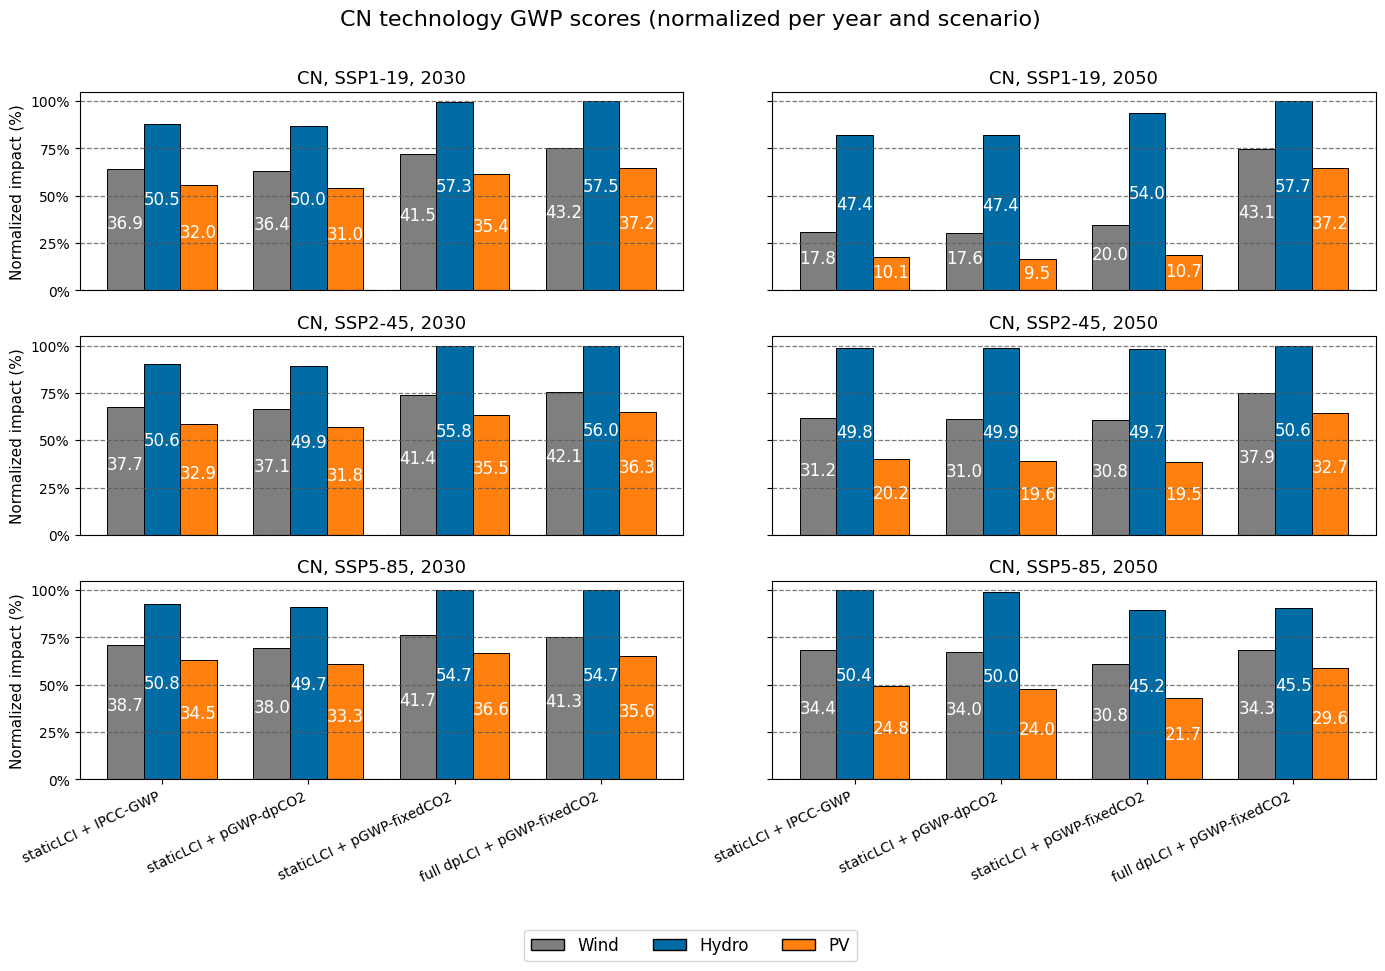

In [7]:
# let's filter out only three metric (caz we not suggest using pGWP100-dpCO2 anyways)

metric_order = [
    "staticLCI + IPCC-GWP",
    "staticLCI + pGWP-dpCO2",
    "staticLCI + pGWP-fixedCO2",
    #"dyn-FG-LCI + pGWP-fixedCO2",
    "full dpLCI + pGWP-fixedCO2"
]

tech_colors = {"PV":"#FF800E","Wind": "#7F7F7F" ,"Hydro": "#006BA4"}

df_full_filt = df_full[df_full["Metric"].isin(metric_order)].copy()


fig, axes = plot_bar_oneregion_twoyears(
    df_full=df_full_filt,
    years=(2030, 2050),
    country="CN",
    metric_order=metric_order,
    metric_labels=metric_labels,
    tech_colors=tech_colors,
)
